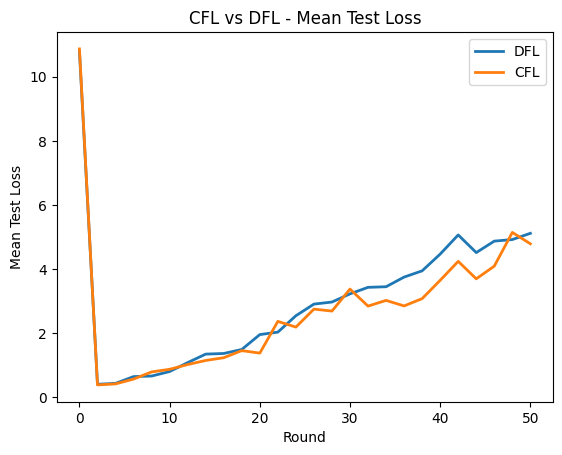

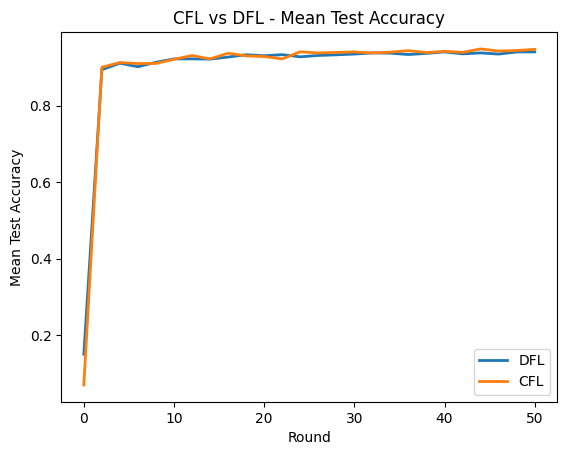

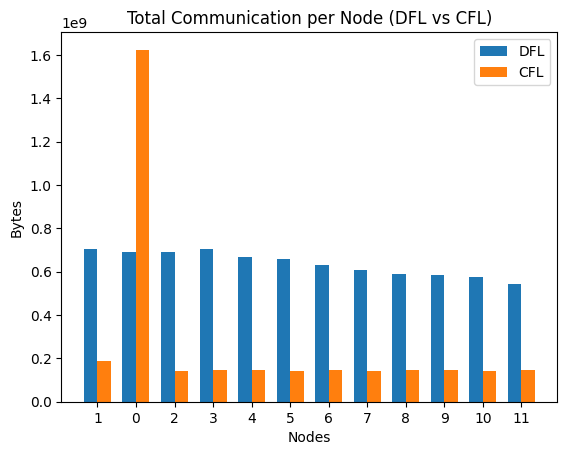

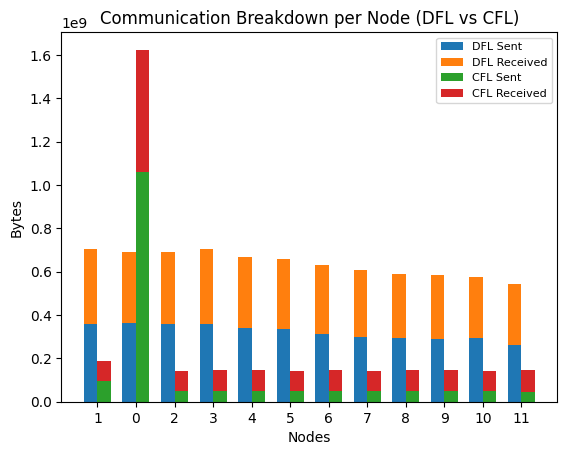

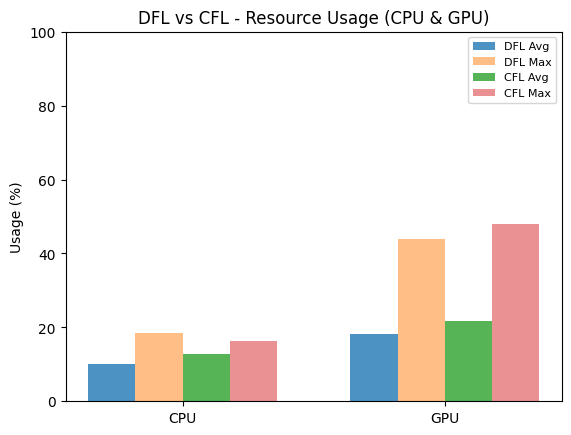

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ========================
# CONFIG
# ========================
BASE_DIR = Path("../../results")

DFL_NAME = "normal_n12_r50_e1_bs32"
DFL_DIR = BASE_DIR / DFL_NAME
CFL_DIR = BASE_DIR / f"cfl_{DFL_NAME}"

IMAGE_DIR = Path("images_compare") / DFL_NAME
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


# ========================
# LOAD FUNCTION
# ========================
def load_mean_metrics(result_dir):
    with open(result_dir / "metrics.json", "r") as f:
        data = json.load(f)

    df = pd.DataFrame(data)

    loss_df = df[df["metric"] == "test_loss"]
    acc_df = df[df["metric"] == "test_metric"]
    
    loss_df = loss_df[loss_df["round"] % 2 == 0]
    acc_df = acc_df[acc_df["round"] % 2 == 0]

    loss_mean = (
        loss_df.groupby("round")["value"]
        .mean()
        .reset_index()
    )

    acc_mean = (
        acc_df.groupby("round")["value"]
        .mean()
        .reset_index()
    )

    return loss_mean, acc_mean


# ========================
# LOAD DATA
# ========================
dfl_loss, dfl_acc = load_mean_metrics(DFL_DIR)
cfl_loss, cfl_acc = load_mean_metrics(CFL_DIR)


# ========================
# PLOT LOSS
# ========================
plt.figure()

plt.plot(dfl_loss["round"], dfl_loss["value"], label="DFL", linewidth=2)
plt.plot(cfl_loss["round"], cfl_loss["value"], label="CFL", linewidth=2)

plt.xlabel("Round")
plt.ylabel("Mean Test Loss")
plt.title("CFL vs DFL - Mean Test Loss")
plt.legend()

plt.savefig(IMAGE_DIR / "compare_loss.png", bbox_inches="tight")
plt.show()


# ========================
# PLOT ACCURACY
# ========================
plt.figure()

plt.plot(dfl_acc["round"], dfl_acc["value"], label="DFL", linewidth=2)
plt.plot(cfl_acc["round"], cfl_acc["value"], label="CFL", linewidth=2)

plt.xlabel("Round")
plt.ylabel("Mean Test Accuracy")
plt.title("CFL vs DFL - Mean Test Accuracy")
plt.legend()

plt.savefig(IMAGE_DIR / "compare_accuracy.png", bbox_inches="tight")
plt.show()

import numpy as np

def load_comm(result_dir):
    with open(result_dir / "communication.json", "r") as f:
        return pd.DataFrame(json.load(f))

dfl_comm = load_comm(DFL_DIR)
cfl_comm = load_comm(CFL_DIR)

dfl_comm["total"] = dfl_comm["bytes_sent"] + dfl_comm["bytes_received"]
cfl_comm["total"] = cfl_comm["bytes_sent"] + cfl_comm["bytes_received"]

x = np.arange(len(dfl_comm))
width = 0.35

plt.figure()

plt.bar(x - width/2, dfl_comm["total"], width, label="DFL")
plt.bar(x + width/2, cfl_comm["total"], width, label="CFL")

labels = dfl_comm["node"].astype(str).str.replace("node-", "").str.strip()

plt.xticks(x, dfl_comm["node"])
plt.xlabel("Nodes")
plt.xticks(x, labels)

plt.ylabel("Bytes")
plt.title("Total Communication per Node (DFL vs CFL)")
plt.legend()

plt.savefig(IMAGE_DIR / "compare_comm_total.png", bbox_inches="tight")
plt.show()

plt.figure()

# DFL
plt.bar(x - width/2, dfl_comm["bytes_sent"], width, label="DFL Sent")
plt.bar(
    x - width/2,
    dfl_comm["bytes_received"],
    width,
    bottom=dfl_comm["bytes_sent"],
    label="DFL Received"
)

# CFL
plt.bar(x + width/2, cfl_comm["bytes_sent"], width, label="CFL Sent")
plt.bar(
    x + width/2,
    cfl_comm["bytes_received"],
    width,
    bottom=cfl_comm["bytes_sent"],
    label="CFL Received"
)

plt.xticks(x, dfl_comm["node"])
plt.xlabel("Nodes")
plt.xticks(x, labels)

plt.ylabel("Bytes")
plt.title("Communication Breakdown per Node (DFL vs CFL)")
plt.legend(fontsize=8)

plt.savefig(IMAGE_DIR / "compare_comm_stacked.png", bbox_inches="tight")
plt.show()

def load_resource(result_dir):
    with open(result_dir / "resource.json", "r") as f:
        return pd.DataFrame(json.load(f))

dfl_res = load_resource(DFL_DIR)
cfl_res = load_resource(CFL_DIR)

def summarize_resource(df):
    return {
        "cpu_avg": df["cpu_avg"].mean(),
        "cpu_max": df["cpu_max"].mean(),
        "gpu_avg": df["gpu_avg"].mean(),
        "gpu_max": df["gpu_max"].mean(),
    }

dfl_sum = summarize_resource(dfl_res)
cfl_sum = summarize_resource(cfl_res)

summary_df = pd.DataFrame([
    {
        "metric": "CPU",
        "dfl_avg": dfl_sum["cpu_avg"],
        "dfl_max": dfl_sum["cpu_max"],
        "cfl_avg": cfl_sum["cpu_avg"],
        "cfl_max": cfl_sum["cpu_max"],
    },
    {
        "metric": "GPU",
        "dfl_avg": dfl_sum["gpu_avg"],
        "dfl_max": dfl_sum["gpu_max"],
        "cfl_avg": cfl_sum["gpu_avg"],
        "cfl_max": cfl_sum["gpu_max"],
    },
])

import numpy as np

x = np.arange(len(summary_df))
width = 0.18

plt.figure()

# ===== DFL =====
plt.bar(x - width*1.5, summary_df["dfl_avg"], width, label="DFL Avg", alpha=0.8)
plt.bar(x - width*0.5, summary_df["dfl_max"], width, label="DFL Max", alpha=0.5)

# ===== CFL =====
plt.bar(x + width*0.5, summary_df["cfl_avg"], width, label="CFL Avg", alpha=0.8)
plt.bar(x + width*1.5, summary_df["cfl_max"], width, label="CFL Max", alpha=0.5)

plt.xticks(x, summary_df["metric"])
plt.ylabel("Usage (%)")
plt.ylim(0, 100)
plt.title("DFL vs CFL - Resource Usage (CPU & GPU)")
plt.legend(fontsize=8)

plt.savefig(IMAGE_DIR / "compare_resource.png", bbox_inches="tight")
plt.show()